# Analisi Crittoanalistica di Crittogramma Playfair con Anomalie

**Autore**: Crittoanalisi Master - Modulo 7  
**Data**: Maggio 2026  
**Obiettivo**: Analizzare un crittogramma sospetto Playfair con digrammi doppi anomali  

---

## 1. Introduzione e Ipotesi di Lavoro

### Contesto Crittografico

Il **cifrario di Playfair** è un cifrario a sostituzione polialfabetica che opera su **digrammi** (coppie di lettere). Le caratteristiche principali sono:

1. **Alfabeto ridotto**: 25 lettere (solitamente I/J unificate)
2. **Cifratura a digrammi**: il testo viene diviso in coppie di lettere
3. **Filler per lettere doppie**: nel plaintext, coppie con lettere uguali vengono separate con una X
4. **Padding**: se il testo ha lunghezza dispari, viene aggiunto un filler finale

### Proprietà Fondamentale del Ciphertext Playfair

**Nel ciphertext Playfair standard NON dovrebbero mai comparire digrammi allineati con lettere uguali** (AA, BB, CC, ..., ZZ).

Questo perché:
- Il plaintext non contiene lettere doppie adiacenti (vengono separate con X)
- La matrice Playfair 5×5 rende impossibile che due lettere uguali consecutive nel plaintext producano due lettere uguali consecutive nel ciphertext

### Anomalie Osservate nel Crittogramma

Nel crittogramma in esame sono stati rilevati **digrammi doppi allineati**, che sono incompatibili con Playfair standard.

### Possibili Spiegazioni

1. **Non è Playfair**: il cifrario potrebbe essere diverso
2. **Sfasamento**: un carattere extra causa disallineamento dei digrammi
3. **Caratteri nulli**: inseriti intenzionalmente per confondere
4. **Separatori di blocco/frase**: marcatori tra sezioni del messaggio
5. **Sequenze di adattamento**: aggiunte prima o dopo la cifratura
6. **Errori di trasmissione**: caratteri extra inseriti accidentalmente

### Approccio Analitico

**Non concludiamo immediatamente che non sia Playfair.** Invece:

- Analizziamo statisticamente il testo
- Cerchiamo pattern nei digrammi doppi
- Testiamo offset diversi di segmentazione
- Identifichiamo possibili punti di sfasamento
- Valutiamo rimozioni minime di caratteri sospetti
- Generiamo varianti candidate del testo

**Principio**: Un solo carattere extra in posizione N può sfasare **tutti** i digrammi successivi, creando molti doppi illegali.

In [2]:
# Import delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from itertools import combinations
import math

# Configurazione visualizzazioni
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Creazione directory output
output_dir = Path('../output')
output_dir.mkdir(exist_ok=True)

print("✅ Librerie importate")
print(f"✅ Directory output: {output_dir.absolute()}")

✅ Librerie importate
✅ Directory output: /home/xcesco/git/playfair-cracker/notebooks/../output


## 2. Normalizzazione del Crittogramma

Normalizziamo il testo cifrato per l'analisi.

In [3]:
# Crittogramma originale
CRITTOGRAMMA_RAW = """
VIANPGMIIMQCTLQVPQRCFINUVOLUNTICGZSYNAQYPGFIMNTDNGGBFIMNIOVOHI
NLMIVYRCLTLHNQBRQCTORCXYCGATIMCRIHSBRQYLUKLYHEIHIALWIFANMKDIDF
ACTORCAIQNPMQVPYLCLWLNYVFDLYWICKGNUZUKCRQRITHIFIVOMAQRYZGUNL
UNTLBHEGNLRIYBQKCLTRCUNPGQNMUCTYLLBDVTORCUAQZMGYVMPDVANMKC
SFILCOVIFLNMPNQANMGPGCQNANLLHRYPOVIAIKUNMLYFDLNYXMYCLIYALKCMN
TOKCLNYMIHCRMBQPBGFINGAILHIXIHCGYMGOAUNQIMHLLBHLDPTNMKLBHEGNI
FCRLFZCDCMUQNNPYMUCTNNTMXLHHLKCLELERYVDLYQZMGVDBXTANAAMTER
CLKLCQNMYHITMWCETAIAMQRIZNLVOGMQBIAATEACHLWLNUNIFAXUATLYHGCA
ISNTNUGVDRQQBIAHICLNHSYNLLCLYANDURCCLDONUNACMNPNGIFGKBLFDLYW
ICKGNUZUKCRCGZMYRDOMDIYQLKMIMLWIFCRVIDHPNVOLHMPLZLRLWNPQBBG
CKMOBLLBCRNTOPFDGNIFMGICCKHIYMUMDOVOLHNQQBCKUGVDLHDHPNVOLH
NQCTBLLNYVCLHYLWIFIGNALHMTDIQVPQRCFINUVONTLBYZYLNPHIATLYANCGY
RXYCRYMTDRCUMHYHEGNHYTLTAAIKUNMLYCLGELHFINUQNCIYXRCHYHIIHUAQZ
MGVDYXRCCKLVDVWINGGUUKLBLBYIAIQLANPGRLDISNCKATHCANYCNLNPKGDH
AMNTLBKGFIRYVDMGHYCKIFIHYCNLAINLDFLHGNTDSYUMUGVDLEYHLHNQQBCK
UGVDBQRCVIXILBCGSYBHSYUMANSBPNRXNMLYNGMTDIQVPQRCFINUVONTLBYZ
YLNPMKCKNTUNFIMNIOVOSYGMRCUDNPFIGBDURCMPIMIDGNANYMUCTNIMUGV
DBQWCETAIAMHYQROQNMYMQCVIQCQZMKLZINQYUMNGANMQMUDFVIMIKMLHI
HSBYHBHNTNLFICKUALBVIEILCTLANQPPGHCHLLWGBVDAIDFACMPMWEWETAIM
NGLRQNPHYIQRQMKLZINVOLCUMNGNTUNFIVOHIOVDFVIMIKMLHIHSBYHBHNTN
LHCYMTLYLWIMNIVTDNGBHNGCHHEHLIKNPLBPGPORQMKLZINQYUMNGGBKMQC
QZMPSBRQYLLBMZGQNLQYHLKCTNTIMGHYATTNMRMCIDQPQZMGCTHLTMPNRQ
NAAIPOVIAIKUNMLYCGQRYZFIMURQMKNTFINPFDNHQYMGSBVYAMCRICQBCKCH
LNTDPCSKUNMTNIHDPNPHYHENQCTBLLNYVCLHYLWIFIGNALHMTDIQVPQRCFIN
UVONTLBYZYLNP
"""

In [4]:
@dataclass
class NormalizationResult:
    """Risultato della normalizzazione del crittogramma."""
    original_text: str
    normalized_text: str
    original_length: int
    normalized_length: int
    removed_chars: str
    alphabet_used: str
    missing_letters: List[str]
    letter_frequencies: pd.DataFrame
    has_j: bool
    is_even_length: bool


def normalize_ciphertext(text: str, alphabet: str = "ABCDEFGHIJKLMNOPQRSTUVWXYZ") -> NormalizationResult:
    """
    Normalizza il crittogramma rimuovendo caratteri non alfabetici.
    
    Args:
        text: Testo da normalizzare
        alphabet: Alfabeto di riferimento
    
    Returns:
        NormalizationResult con tutte le metriche
    """
    original = text
    original_length = len(original)
    
    # Conversione maiuscolo
    text_upper = text.upper()
    
    # Rimozione caratteri non alfabetici
    alphabet_set = set(alphabet)
    normalized = ''.join(c for c in text_upper if c in alphabet_set)
    
    # Caratteri rimossi
    removed = ''.join(c for c in text_upper if c not in alphabet_set)
    
    # Lettere presenti
    letters_present = sorted(set(normalized))
    missing = sorted(set(alphabet) - set(normalized))
    
    # Frequenze
    freq_counter = Counter(normalized)
    total = len(normalized)
    
    freq_df = pd.DataFrame([
        {
            'lettera': letter,
            'frequenza': freq_counter.get(letter, 0),
            'percentuale': 100 * freq_counter.get(letter, 0) / total if total > 0 else 0
        }
        for letter in alphabet
    ]).sort_values('frequenza', ascending=False).reset_index(drop=True)
    
    return NormalizationResult(
        original_text=original,
        normalized_text=normalized,
        original_length=original_length,
        normalized_length=len(normalized),
        removed_chars=removed,
        alphabet_used=''.join(letters_present),
        missing_letters=missing,
        letter_frequencies=freq_df,
        has_j='J' in normalized,
        is_even_length=len(normalized) % 2 == 0
    )


# Normalizzazione
norm_result = normalize_ciphertext(CRITTOGRAMMA_RAW)

print("="*70)
print("NORMALIZZAZIONE CRITTOGRAMMA")
print("="*70)
print(f"Lunghezza originale:    {norm_result.original_length:>6} caratteri")
print(f"Lunghezza normalizzata: {norm_result.normalized_length:>6} caratteri")
print(f"Caratteri rimossi:      {norm_result.removed_chars[:50]}..." if len(norm_result.removed_chars) > 50 else f"Caratteri rimossi:      '{norm_result.removed_chars}'")
print(f"Parità lunghezza:       {'PARI ✓' if norm_result.is_even_length else 'DISPARI ✗'}")
print(f"Presenza J:             {'SÌ ✗' if norm_result.has_j else 'NO ✓'}")
print(f"Lettere presenti:       {len(norm_result.alphabet_used)}/26")
print(f"Lettere mancanti:       {', '.join(norm_result.missing_letters) if norm_result.missing_letters else 'Nessuna'}")
print("="*70)

# Salvataggio testo normalizzato
with open(output_dir / 'normalized_cipher.txt', 'w') as f:
    f.write(norm_result.normalized_text)

print(f"\n✅ Salvato: {output_dir / 'normalized_cipher.txt'}")

NORMALIZZAZIONE CRITTOGRAMMA
Lunghezza originale:      1474 caratteri
Lunghezza normalizzata:   1448 caratteri
Caratteri rimossi:      '

























'
Parità lunghezza:       PARI ✓
Presenza J:             NO ✓
Lettere presenti:       25/26
Lettere mancanti:       J

✅ Salvato: ../output/normalized_cipher.txt


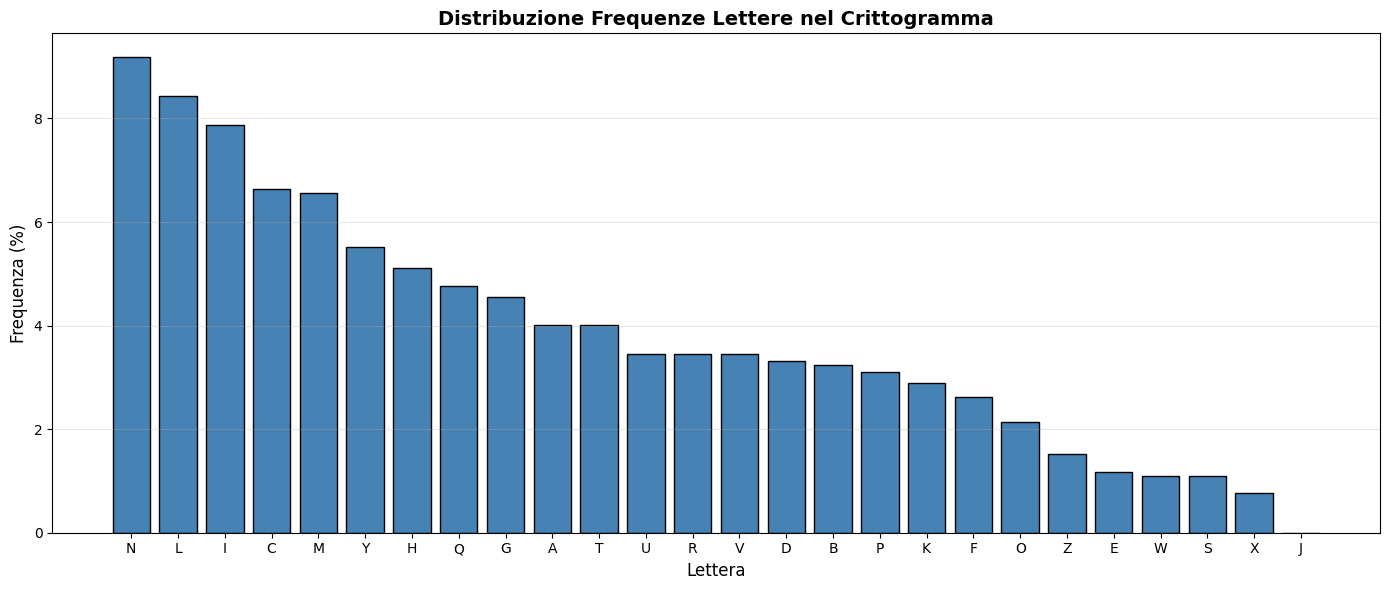


📊 Top 10 lettere più frequenti:
lettera  frequenza  percentuale
      N        133     9.185083
      L        122     8.425414
      I        114     7.872928
      C         96     6.629834
      M         95     6.560773
      Y         80     5.524862
      H         74     5.110497
      Q         69     4.765193
      G         66     4.558011
      A         58     4.005525


In [5]:
# Visualizzazione frequenze lettere
top_letters = norm_result.letter_frequencies.head(26)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(top_letters['lettera'], top_letters['percentuale'], color='steelblue', edgecolor='black')
ax.set_xlabel('Lettera', fontsize=12)
ax.set_ylabel('Frequenza (%)', fontsize=12)
ax.set_title('Distribuzione Frequenze Lettere nel Crittogramma', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 10 lettere più frequenti:")
print(norm_result.letter_frequencies.head(10).to_string(index=False))

### Interpretazione Normalizzazione

**Compatibilità con Playfair**:
- ✅ **Assenza di J**: compatibile con Playfair I/J unificati
- ✅ **Lunghezza pari**: compatibile con segmentazione in digrammi
- ⚠️ **Lettere mancanti**: verifichiamo se influenzano l'analisi

**Prossimi passi**: segmentare in digrammi e cercare anomalie.

## 3. Segmentazione in Digrammi

Segmentiamo il testo in digrammi con diversi offset per rilevare possibili sfasamenti.

In [6]:
@dataclass
class DigramData:
    """Informazioni su un digramma."""
    digram_index: int
    start_pos: int  # 1-based
    end_pos: int    # 1-based
    digram: str
    first: str
    second: str
    is_double: bool
    context_before: str
    context_after: str


def split_digrams(text: str, offset: int = 0, context_size: int = 12) -> List[DigramData]:
    """
    Divide il testo in digrammi con offset specificato.
    
    Args:
        text: Testo normalizzato
        offset: Numero di caratteri da saltare all'inizio (0 o 1)
        context_size: Caratteri di contesto prima/dopo
    
    Returns:
        Lista di DigramData
    """
    digrams = []
    start_idx = offset
    
    idx = 0
    while start_idx + 1 < len(text):
        # Estrazione digramma
        first = text[start_idx]
        second = text[start_idx + 1]
        digram = first + second
        
        # Contesto
        ctx_before_start = max(0, start_idx - context_size)
        context_before = text[ctx_before_start:start_idx]
        
        ctx_after_end = min(len(text), start_idx + 2 + context_size)
        context_after = text[start_idx + 2:ctx_after_end]
        
        digrams.append(DigramData(
            digram_index=idx,
            start_pos=start_idx + 1,  # 1-based
            end_pos=start_idx + 2,     # 1-based
            digram=digram,
            first=first,
            second=second,
            is_double=(first == second),
            context_before=context_before,
            context_after=context_after
        ))
        
        idx += 1
        start_idx += 2
    
    return digrams


# Segmentazione con offset 0 e 1
ciphertext = norm_result.normalized_text

digrams_offset0 = split_digrams(ciphertext, offset=0)
digrams_offset1 = split_digrams(ciphertext, offset=1)

print("="*70)
print("SEGMENTAZIONE IN DIGRAMMI")
print("="*70)
print(f"Offset 0: {len(digrams_offset0)} digrammi")
print(f"Offset 1: {len(digrams_offset1)} digrammi")
print("="*70)

# Conversione a DataFrame
df_offset0 = pd.DataFrame([vars(d) for d in digrams_offset0])
df_offset1 = pd.DataFrame([vars(d) for d in digrams_offset1])

# Salvataggio
df_offset0.to_csv(output_dir / 'digrams_offset0.csv', index=False)
df_offset1.to_csv(output_dir / 'digrams_offset1.csv', index=False)

print(f"\n✅ Salvati: digrams_offset0.csv, digrams_offset1.csv")

# Primi 10 digrammi offset 0
print("\n📊 Primi 10 digrammi (offset=0):")
print(df_offset0[['digram_index', 'start_pos', 'digram', 'is_double']].head(10).to_string(index=False))

SEGMENTAZIONE IN DIGRAMMI
Offset 0: 724 digrammi
Offset 1: 723 digrammi

✅ Salvati: digrams_offset0.csv, digrams_offset1.csv

📊 Primi 10 digrammi (offset=0):
 digram_index  start_pos digram  is_double
            0          1     VI      False
            1          3     AN      False
            2          5     PG      False
            3          7     MI      False
            4          9     IM      False
            5         11     QC      False
            6         13     TL      False
            7         15     QV      False
            8         17     PQ      False
            9         19     RC      False


## 4. Analisi Frequenze dei Digrammi

Analizziamo la distribuzione delle frequenze dei digrammi.

In [7]:
def analyze_digram_frequencies(digrams: List[DigramData]) -> pd.DataFrame:
    """
    Calcola statistiche di frequenza sui digrammi.
    
    Returns:
        DataFrame con frequenze ordinate
    """
    digram_list = [d.digram for d in digrams]
    freq_counter = Counter(digram_list)
    total = len(digram_list)
    
    freq_df = pd.DataFrame([
        {
            'digramma': dig,
            'frequenza': count,
            'percentuale': 100 * count / total
        }
        for dig, count in freq_counter.items()
    ]).sort_values('frequenza', ascending=False).reset_index(drop=True)
    
    return freq_df


# Analisi frequenze offset 0
freq_offset0 = analyze_digram_frequencies(digrams_offset0)
freq_offset1 = analyze_digram_frequencies(digrams_offset1)

print("="*70)
print("STATISTICHE DIGRAMMI (OFFSET 0)")
print("="*70)
print(f"Digrammi totali:     {len(digrams_offset0)}")
print(f"Digrammi distinti:   {len(freq_offset0)}")
print(f"Massimo teorico:     625 (25×25)")
print(f"Copertura:           {100 * len(freq_offset0) / 625:.2f}%")
print("="*70)

print("\n📊 Top 20 digrammi più frequenti (offset=0):")
print(freq_offset0.head(20).to_string(index=False))

STATISTICHE DIGRAMMI (OFFSET 0)
Digrammi totali:     724
Digrammi distinti:   309
Massimo teorico:     625 (25×25)
Copertura:           49.44%

📊 Top 20 digrammi più frequenti (offset=0):
digramma  frequenza  percentuale
      IM          9     1.243094
      NM          9     1.243094
      LL          8     1.104972
      FI          7     0.966851
      ML          7     0.966851
      GV          7     0.966851
      NT          7     0.966851
      MN          7     0.966851
      KL          7     0.966851
      IN          7     0.966851
      IA          7     0.966851
      HN          6     0.828729
      NI          6     0.828729
      UN          6     0.828729
      LN          6     0.828729
      CL          6     0.828729
      QN          6     0.828729
      ZM          6     0.828729
      RC          6     0.828729
      TL          6     0.828729


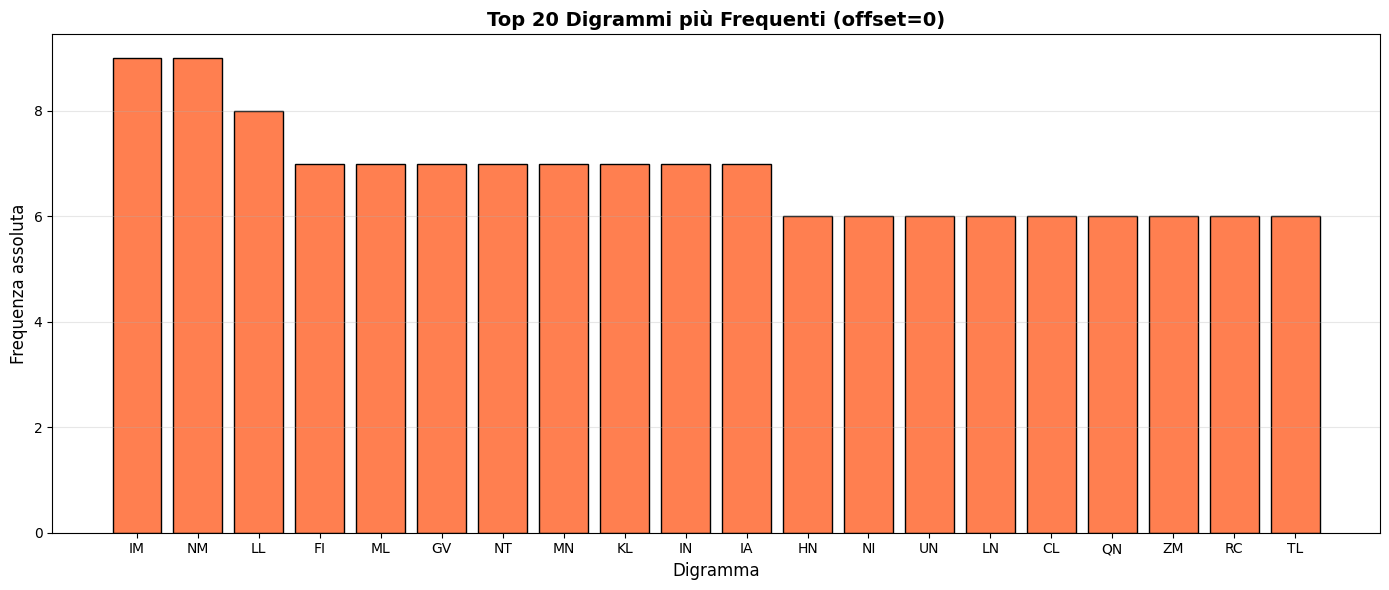

In [8]:
# Visualizzazione top 20 digrammi
top20 = freq_offset0.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(top20)), top20['frequenza'], color='coral', edgecolor='black')
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20['digramma'], rotation=0, fontsize=10)
ax.set_xlabel('Digramma', fontsize=12)
ax.set_ylabel('Frequenza assoluta', fontsize=12)
ax.set_title('Top 20 Digrammi più Frequenti (offset=0)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

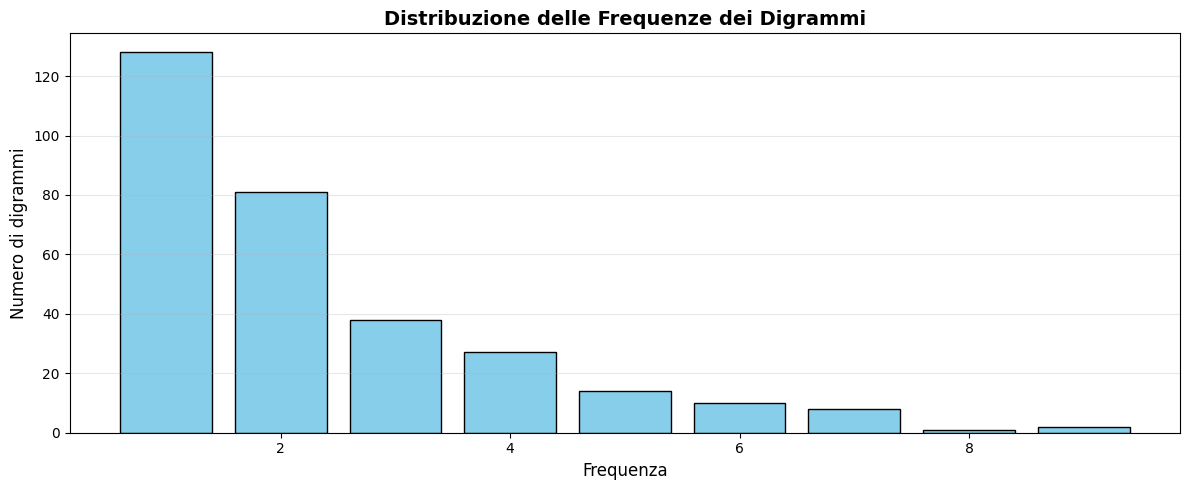


📈 Digrammi ripetuti: 181/309 (58.6%)


In [9]:
# Distribuzione frequenze
freq_distribution = freq_offset0['frequenza'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(freq_distribution.index, freq_distribution.values, color='skyblue', edgecolor='black')
ax.set_xlabel('Frequenza', fontsize=12)
ax.set_ylabel('Numero di digrammi', fontsize=12)
ax.set_title('Distribuzione delle Frequenze dei Digrammi', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Indice di ripetizione
repeated_digrams = freq_offset0[freq_offset0['frequenza'] > 1]
repetition_rate = 100 * len(repeated_digrams) / len(freq_offset0)

print(f"\n📈 Digrammi ripetuti: {len(repeated_digrams)}/{len(freq_offset0)} ({repetition_rate:.1f}%)")

## 5. Analisi dei Digrammi Doppi (Anomalie Playfair)

**PUNTO CRITICO**: Cerchiamo i digrammi allineati con lettere uguali (AA, BB, CC, ..., ZZ).

Questi sono **impossibili** nel Playfair standard e rappresentano anomalie strutturali.

In [10]:
def find_double_digrams(digrams: List[DigramData]) -> pd.DataFrame:
    """
    Trova tutti i digrammi doppi allineati (AA, BB, ...).
    
    Returns:
        DataFrame con digrammi doppi e contesto
    """
    doubles = []
    
    for i, d in enumerate(digrams):
        if d.is_double:
            # Digrammi precedente e successivo
            prev_digram = digrams[i-1].digram if i > 0 else "--"
            next_digram = digrams[i+1].digram if i < len(digrams) - 1 else "--"
            
            # Distanza dal doppio precedente
            dist_from_prev = None
            for j in range(i-1, -1, -1):
                if digrams[j].is_double:
                    dist_from_prev = d.start_pos - digrams[j].start_pos
                    break
            
            # Contesto completo
            context_full = f"...{d.context_before}{d.digram}{d.context_after}..."
            
            doubles.append({
                'digram_index': d.digram_index,
                'start_pos': d.start_pos,
                'end_pos': d.end_pos,
                'doppio': d.digram,
                'digramma_precedente': prev_digram,
                'digramma_successivo': next_digram,
                'contesto': context_full,
                'distanza_doppio_prec': dist_from_prev
            })
    
    return pd.DataFrame(doubles)


# Trova doppi con offset 0 e 1
doubles_offset0 = find_double_digrams(digrams_offset0)
doubles_offset1 = find_double_digrams(digrams_offset1)

print("="*70)
print("DIGRAMMI DOPPI ALLINEATI (ANOMALIE PLAYFAIR)")
print("="*70)
print(f"Offset 0: {len(doubles_offset0)} digrammi doppi trovati")
print(f"Offset 1: {len(doubles_offset1)} digrammi doppi trovati")
print("="*70)

# Salvataggio
doubles_offset0.to_csv(output_dir / 'double_digrams_offset0.csv', index=False)
doubles_offset1.to_csv(output_dir / 'double_digrams_offset1.csv', index=False)

print(f"\n✅ Salvati: double_digrams_offset0.csv, double_digrams_offset1.csv")

DIGRAMMI DOPPI ALLINEATI (ANOMALIE PLAYFAIR)
Offset 0: 29 digrammi doppi trovati
Offset 1: 3 digrammi doppi trovati

✅ Salvati: double_digrams_offset0.csv, double_digrams_offset1.csv


In [11]:
# Visualizzazione doppi offset 0
print("\n⚠️  DIGRAMMI DOPPI ALLINEATI (OFFSET=0) - DETTAGLIO COMPLETO:")
print("="*100)

if len(doubles_offset0) > 0:
    for _, row in doubles_offset0.iterrows():
        print(f"Posizione {row['start_pos']:3d}–{row['end_pos']:3d}: {row['doppio']} | "
              f"Precedente: {row['digramma_precedente']:>2} | "
              f"Successivo: {row['digramma_successivo']:>2} | "
              f"Contesto: {row['contesto']}")
        if pd.notna(row['distanza_doppio_prec']):
            print(f"            └─ Distanza dal doppio precedente: {int(row['distanza_doppio_prec'])} posizioni\n")
        else:
            print(f"            └─ Primo doppio nel testo\n")
else:
    print("Nessun digramma doppio trovato con offset=0")

print("="*100)


⚠️  DIGRAMMI DOPPI ALLINEATI (OFFSET=0) - DETTAGLIO COMPLETO:
Posizione 217–218: LL | Precedente: TY | Successivo: BD | Contesto: ...CUNPGQNMUCTYLLBDVTORCUAQZM...
            └─ Primo doppio nel testo

Posizione 269–270: LL | Precedente: AN | Successivo: HR | Contesto: ...QANMGPGCQNANLLHRYPOVIAIKUN...
            └─ Distanza dal doppio precedente: 52 posizioni

Posizione 347–348: LL | Precedente: MH | Successivo: BH | Contesto: ...GYMGOAUNQIMHLLBHLDPTNMKLBH...
            └─ Distanza dal doppio precedente: 78 posizioni

Posizione 377–378: NN | Precedente: UQ | Successivo: PY | Contesto: ...FCRLFZCDCMUQNNPYMUCTNNTMXL...
            └─ Distanza dal doppio precedente: 30 posizioni

Posizione 385–386: NN | Precedente: CT | Successivo: TM | Contesto: ...CMUQNNPYMUCTNNTMXLHHLKCLEL...
            └─ Distanza dal doppio precedente: 8 posizioni

Posizione 391–392: HH | Precedente: XL | Successivo: LK | Contesto: ...PYMUCTNNTMXLHHLKCLELERYVDL...
            └─ Distanza dal doppio precedente: 6 

### Interpretazione Digrammi Doppi

**Significato delle Anomalie**:

1. **Incompatibilità con Playfair standard**: Ogni digramma doppio allineato è una **violazione strutturale**
2. **Possibili cause**:
   - Sfasamento: carattere extra prima del doppio
   - Separatore: il doppio stesso è un marcatore
   - Padding: caratteri di riempimento
   - Errore: cifratura o trasmissione

3. **Pattern da cercare**:
   - Doppi raggruppati (cluster)
   - Distanze regolari tra doppi
   - Digramma precedente/successivo ricorrente

## 6. Confronto Offset 0 vs Offset 1

Confrontiamo il numero di anomalie con segmentazione diversa.

In [12]:
# Tabella comparativa
comparison = pd.DataFrame([
    {
        'offset': 0,
        'num_digrammi': len(digrams_offset0),
        'num_doppi': len(doubles_offset0),
        'percentuale_doppi': 100 * len(doubles_offset0) / len(digrams_offset0),
        'primo_doppio': doubles_offset0['doppio'].iloc[0] if len(doubles_offset0) > 0 else "--",
        'pos_primo_doppio': doubles_offset0['start_pos'].iloc[0] if len(doubles_offset0) > 0 else None,
        'pos_ultimo_doppio': doubles_offset0['start_pos'].iloc[-1] if len(doubles_offset0) > 0 else None
    },
    {
        'offset': 1,
        'num_digrammi': len(digrams_offset1),
        'num_doppi': len(doubles_offset1),
        'percentuale_doppi': 100 * len(doubles_offset1) / len(digrams_offset1),
        'primo_doppio': doubles_offset1['doppio'].iloc[0] if len(doubles_offset1) > 0 else "--",
        'pos_primo_doppio': doubles_offset1['start_pos'].iloc[0] if len(doubles_offset1) > 0 else None,
        'pos_ultimo_doppio': doubles_offset1['start_pos'].iloc[-1] if len(doubles_offset1) > 0 else None
    }
])

print("="*70)
print("CONFRONTO OFFSET 0 vs OFFSET 1")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

# Interpretazione
delta_doppi = abs(len(doubles_offset0) - len(doubles_offset1))
print(f"\n📊 Differenza doppi: {delta_doppi}")

if delta_doppi > 3:
    better_offset = 0 if len(doubles_offset0) < len(doubles_offset1) else 1
    print(f"⚠️  Offset {better_offset} ha significativamente MENO doppi: possibile indicatore di sfasamento")
else:
    print("ℹ️  Entrambi gli offset hanno numero simile di doppi: sfasamento globale improbabile")

CONFRONTO OFFSET 0 vs OFFSET 1
 offset  num_digrammi  num_doppi  percentuale_doppi primo_doppio  pos_primo_doppio  pos_ultimo_doppio
      0           724         29           4.005525           LL               217               1317
      1           723          3           0.414938           II                 8               1404

📊 Differenza doppi: 26
⚠️  Offset 1 ha significativamente MENO doppi: possibile indicatore di sfasamento


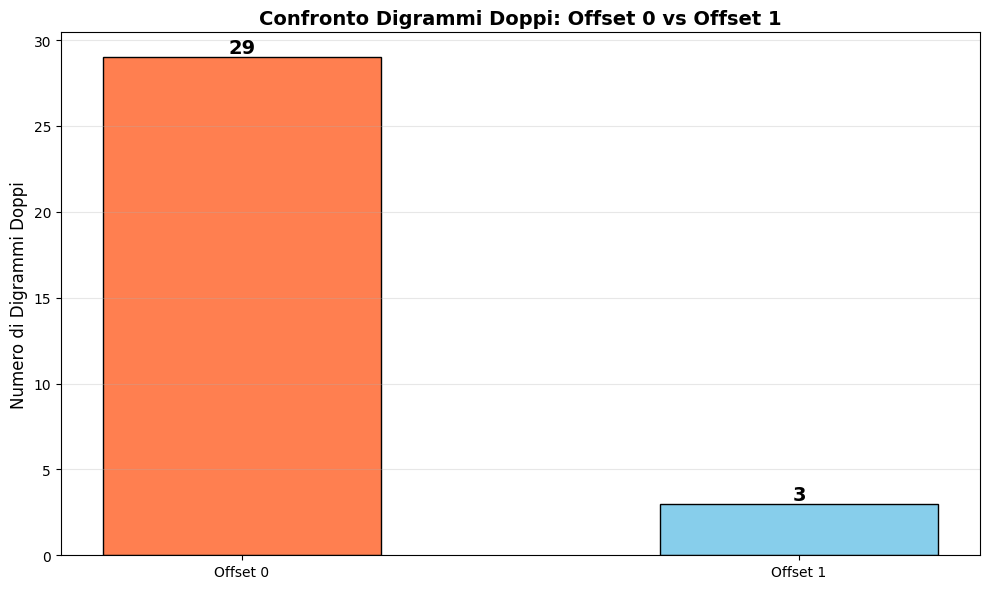

In [13]:
# Visualizzazione grafica confronto
fig, ax = plt.subplots(figsize=(10, 6))

offsets = ['Offset 0', 'Offset 1']
num_doppi = [len(doubles_offset0), len(doubles_offset1)]

bars = ax.bar(offsets, num_doppi, color=['coral', 'skyblue'], edgecolor='black', width=0.5)

# Aggiungi valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Numero di Digrammi Doppi', fontsize=12)
ax.set_title('Confronto Digrammi Doppi: Offset 0 vs Offset 1', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Ricerca Doppi Non Allineati

**ANALISI CRUCIALE**: Cerchiamo coppie di lettere uguali consecutive nel testo, **indipendentemente** dall'allineamento dei digrammi.

Un doppio non allineato potrebbe essere:
- Un **separatore** tra blocchi
- Un **carattere extra** che causa sfasamento successivo
- Un **null character** da rimuovere

In [14]:
@dataclass
class AdjacentDouble:
    """Doppio adiacente non allineato."""
    position: int  # 1-based posizione prima lettera
    double: str
    is_aligned: bool  # True se cade su confine digramma offset=0
    digram_before: Optional[str]
    digram_after: Optional[str]
    context: str


def find_adjacent_doubles(text: str, context_size: int = 12) -> List[AdjacentDouble]:
    """
    Trova tutte le coppie di lettere uguali consecutive, allineate o no.
    """
    adjacent_doubles = []
    
    for i in range(len(text) - 1):
        if text[i] == text[i+1]:
            pos_1based = i + 1
            double = text[i] * 2
            
            # Verifica allineamento con offset=0
            # Posizione pari (1-based) = inizio digramma
            is_aligned = (pos_1based % 2 == 1)
            
            # Digrammi precedente/successivo (offset 0)
            digram_idx = (pos_1based - 1) // 2
            
            digram_before = None
            if digram_idx > 0:
                start_prev = (digram_idx - 1) * 2
                digram_before = text[start_prev:start_prev+2]
            
            digram_after = None
            if is_aligned:
                # Il doppio stesso è un digramma
                next_start = (digram_idx + 1) * 2
                if next_start + 1 < len(text):
                    digram_after = text[next_start:next_start+2]
            else:
                # Il doppio attraversa due digrammi
                next_start = (digram_idx + 1) * 2
                if next_start + 1 < len(text):
                    digram_after = text[next_start:next_start+2]
            
            # Contesto
            ctx_start = max(0, i - context_size)
            ctx_end = min(len(text), i + 2 + context_size)
            context = f"...{text[ctx_start:i]}{double}{text[i+2:ctx_end]}..."
            
            adjacent_doubles.append(AdjacentDouble(
                position=pos_1based,
                double=double,
                is_aligned=is_aligned,
                digram_before=digram_before,
                digram_after=digram_after,
                context=context
            ))
    
    return adjacent_doubles


# Trova tutti i doppi adiacenti
adjacent_doubles = find_adjacent_doubles(ciphertext)

df_adjacent = pd.DataFrame([vars(d) for d in adjacent_doubles])
df_adjacent.to_csv(output_dir / 'adjacent_doubles.csv', index=False)

print("="*70)
print("DOPPI ADIACENTI (ALLINEATI E NON)")
print("="*70)
print(f"Totale doppi adiacenti: {len(adjacent_doubles)}")
print(f"Allineati (offset=0):   {sum(1 for d in adjacent_doubles if d.is_aligned)}")
print(f"NON allineati:          {sum(1 for d in adjacent_doubles if not d.is_aligned)}")
print("="*70)

print(f"\n✅ Salvato: adjacent_doubles.csv")

DOPPI ADIACENTI (ALLINEATI E NON)
Totale doppi adiacenti: 32
Allineati (offset=0):   29
NON allineati:          3

✅ Salvato: adjacent_doubles.csv


In [15]:
# Visualizzazione doppi NON allineati (i più interessanti)
non_aligned = [d for d in adjacent_doubles if not d.is_aligned]

print("\n⚠️  DOPPI NON ALLINEATI (CANDIDATI SEPARATORI/SFASAMENTO):")
print("="*100)

if len(non_aligned) > 0:
    for d in non_aligned:
        print(f"Posizione {d.position:3d}: {d.double} | "
              f"Allineato: {'SÌ' if d.is_aligned else 'NO'} | "
              f"Digr.prec: {d.digram_before or '--':>2} | "
              f"Digr.succ: {d.digram_after or '--':>2}")
        print(f"            Contesto: {d.context}")
        print()
else:
    print("Nessun doppio non allineato trovato")

print("="*100)


⚠️  DOPPI NON ALLINEATI (CANDIDATI SEPARATORI/SFASAMENTO):
Posizione   8: II | Allineato: NO | Digr.prec: PG | Digr.succ: IM
            Contesto: ...VIANPGMIIMQCTLQVPQRCF...

Posizione  50: GG | Allineato: NO | Digr.prec: TD | Digr.succ: GB
            Contesto: ...AQYPGFIMNTDNGGBFIMNIOVOHIN...

Posizione 1404: LL | Allineato: NO | Digr.prec: CT | Digr.succ: LN
            Contesto: ...PNPHYHENQCTBLLNYVCLHYLWIFI...



### Interpretazione Doppi Non Allineati

**Perché i doppi NON allineati sono più interessanti**:

1. Un doppio **allineato** è un'anomalia Playfair, ma è parte del flusso dei digrammi
2. Un doppio **NON allineato** **attraversa** il confine tra due digrammi:
   - Prima lettera appartiene al digramma N
   - Seconda lettera appartiene al digramma N+1
   - Questo è **ancora più anomalo** e suggerisce:
     - Possibile separatore inserito tra blocchi
     - Carattere extra che causa sfasamento
     - Null character da rimuovere

## 8. Simulazione Rimozione Singola (Punti di Sfasamento)

**Test di compatibilità strutturale**: Simuliamo la rimozione di un singolo carattere e verifichiamo se riduce le anomalie.

**IMPORTANTE**: Non stiamo dicendo che questi caratteri DEVONO essere rimossi. Stiamo solo **testando** l'ipotesi che siano separatori o caratteri extra.

In [16]:
@dataclass
class DeletionResult:
    """Risultato della simulazione di rimozione."""
    position: int  # 1-based
    char_removed: str
    new_length: int
    is_even: bool
    num_doubles_offset0: int
    num_doubles_offset1: int
    delta_offset0: int
    delta_offset1: int
    first_doubles_offset0: str
    context: str


def evaluate_single_deletion(text: str, pos_1based: int, context_size: int = 12) -> DeletionResult:
    """
    Simula rimozione di un carattere e calcola impatto sulle anomalie.
    """
    # Rimozione
    idx_0based = pos_1based - 1
    char_removed = text[idx_0based]
    new_text = text[:idx_0based] + text[idx_0based+1:]
    
    # Nuova segmentazione
    new_digrams_0 = split_digrams(new_text, offset=0)
    new_digrams_1 = split_digrams(new_text, offset=1)
    
    new_doubles_0 = sum(1 for d in new_digrams_0 if d.is_double)
    new_doubles_1 = sum(1 for d in new_digrams_1 if d.is_double)
    
    # Baseline attuali
    baseline_0 = len(doubles_offset0)
    baseline_1 = len(doubles_offset1)
    
    # Primi doppi residui
    first_doubles = ", ".join([d.digram for d in new_digrams_0 if d.is_double][:5])
    if not first_doubles:
        first_doubles = "Nessuno"
    
    # Contesto
    ctx_start = max(0, idx_0based - context_size)
    ctx_end = min(len(text), idx_0based + 1 + context_size)
    context = f"...{text[ctx_start:idx_0based]}[{char_removed}]{text[idx_0based+1:ctx_end]}..."
    
    return DeletionResult(
        position=pos_1based,
        char_removed=char_removed,
        new_length=len(new_text),
        is_even=(len(new_text) % 2 == 0),
        num_doubles_offset0=new_doubles_0,
        num_doubles_offset1=new_doubles_1,
        delta_offset0=new_doubles_0 - baseline_0,
        delta_offset1=new_doubles_1 - baseline_1,
        first_doubles_offset0=first_doubles,
        context=context
    )


print("Simulando rimozioni singole sui doppi adiacenti e posizioni vicine...")

# Posizioni candidate: doppi adiacenti e vicini
candidate_positions = set()

for d in adjacent_doubles:
    candidate_positions.add(d.position)      # Prima lettera doppio
    candidate_positions.add(d.position + 1)  # Seconda lettera doppio
    if d.position > 1:
        candidate_positions.add(d.position - 1)  # Prima del doppio
    if d.position + 2 <= len(ciphertext):
        candidate_positions.add(d.position + 2)  # Dopo il doppio

candidate_positions = sorted(candidate_positions)

print(f"Posizioni candidate da testare: {len(candidate_positions)}")

# Valutazione
deletion_results = []
for pos in candidate_positions:
    result = evaluate_single_deletion(ciphertext, pos)
    deletion_results.append(result)

df_deletions = pd.DataFrame([vars(r) for r in deletion_results])

# Ordina per delta migliore (riduzioni maggiori)
df_deletions_sorted = df_deletions.sort_values('delta_offset0').reset_index(drop=True)

df_deletions_sorted.to_csv(output_dir / 'deletion_candidates.csv', index=False)

print(f"✅ Salvato: deletion_candidates.csv")
print(f"\nBaseline attuali:")
print(f"  Offset 0: {len(doubles_offset0)} doppi")
print(f"  Offset 1: {len(doubles_offset1)} doppi")

Simulando rimozioni singole sui doppi adiacenti e posizioni vicine...
Posizioni candidate da testare: 126
✅ Salvato: deletion_candidates.csv

Baseline attuali:
  Offset 0: 29 doppi
  Offset 1: 3 doppi


In [17]:
# Top 20 rimozioni migliori
top_deletions = df_deletions_sorted.head(20)

print("\n🔍 TOP 20 RIMOZIONI SINGOLE CHE RIDUCONO ANOMALIE (OFFSET 0):")
print("="*120)
print(f"{'Rank':>4} | {'Pos':>4} | {'Char':>4} | {'Doppi':>6} | {'Delta':>6} | {'Context'}")
print("="*120)

for i, row in top_deletions.iterrows():
    print(f"{i+1:4d} | {row['position']:4d} | {row['char_removed']:>4} | "
          f"{row['num_doubles_offset0']:6d} | {row['delta_offset0']:+6d} | "
          f"{row['context'][:80]}")

print("="*120)


🔍 TOP 20 RIMOZIONI SINGOLE CHE RIDUCONO ANOMALIE (OFFSET 0):
Rank |  Pos | Char |  Doppi |  Delta | Context
   1 |   51 |    G |      1 |    -28 | ...QYPGFIMNTDNG[G]BFIMNIOVOHIN...
   2 |   52 |    B |      1 |    -28 | ...YPGFIMNTDNGG[B]FIMNIOVOHINL...
   3 |   50 |    G |      1 |    -28 | ...AQYPGFIMNTDN[G]GBFIMNIOVOHI...
   4 |  216 |    Y |      1 |    -28 | ...RCUNPGQNMUCT[Y]LLBDVTORCUAQ...
   5 |  217 |    L |      1 |    -28 | ...CUNPGQNMUCTY[L]LBDVTORCUAQZ...
   6 |  218 |    L |      1 |    -28 | ...UNPGQNMUCTYL[L]BDVTORCUAQZM...
   7 |    9 |    I |      2 |    -27 | ...VIANPGMI[I]MQCTLQVPQRCF...
   8 |    8 |    I |      2 |    -27 | ...VIANPGM[I]IMQCTLQVPQRC...
   9 |  268 |    N |      2 |    -27 | ...NQANMGPGCQNA[N]LLHRYPOVIAIK...
  10 |   49 |    N |      2 |    -27 | ...NAQYPGFIMNTD[N]GGBFIMNIOVOH...
  11 |   10 |    M |      2 |    -27 | ...VIANPGMII[M]QCTLQVPQRCFI...
  12 |  219 |    B |      2 |    -27 | ...NPGQNMUCTYLL[B]DVTORCUAQZMG...
  13 |  270 |    L |      2

### Interpretazione Rimozioni Singole

**Cosa significano le rimozioni con delta negativo**:

- **Delta < -3**: Rimozione molto promettente, riduce significativamente le anomalie
- **Delta < 0**: Rimozione utile, migliora la compatibilità Playfair
- **Delta = 0**: Nessun impatto
- **Delta > 0**: Rimozione peggiora la situazione

**ATTENZIONE**: Non rimuovere automaticamente! Questi sono **candidati** da valutare con analisi successive.

## 9. Ricerca Rimozioni Multiple Minime

Proviamo combinazioni di 2-3 rimozioni per minimizzare ulteriormente le anomalie.

In [18]:
@dataclass
class MultiDeletionResult:
    """Risultato rimozione multipla."""
    positions: Tuple[int, ...]
    chars_removed: str
    new_length: int
    is_even: bool
    num_doubles_offset0: int
    delta_offset0: int
    first_doubles: str


def evaluate_multi_deletion(text: str, positions: List[int]) -> MultiDeletionResult:
    """
    Simula rimozione multipla.
    
    Args:
        positions: Lista di posizioni 1-based da rimuovere (in ordine)
    """
    # Ordina decrescente per rimozione sicura
    sorted_pos = sorted(positions, reverse=True)
    
    new_text = text
    chars_removed = []
    
    for pos in sorted_pos:
        idx = pos - 1
        chars_removed.append(new_text[idx])
        new_text = new_text[:idx] + new_text[idx+1:]
    
    chars_removed.reverse()
    
    # Nuova segmentazione
    new_digrams = split_digrams(new_text, offset=0)
    new_doubles = sum(1 for d in new_digrams if d.is_double)
    
    baseline = len(doubles_offset0)
    
    first_doubles = ", ".join([d.digram for d in new_digrams if d.is_double][:5])
    if not first_doubles:
        first_doubles = "Nessuno"
    
    return MultiDeletionResult(
        positions=tuple(sorted(positions)),
        chars_removed=''.join(chars_removed),
        new_length=len(new_text),
        is_even=(len(new_text) % 2 == 0),
        num_doubles_offset0=new_doubles,
        delta_offset0=new_doubles - baseline,
        first_doubles=first_doubles
    )


# Selezioniamo le top 15 posizioni singole migliori
top_single_positions = df_deletions_sorted.head(15)['position'].tolist()

print(f"Testando combinazioni di 2-3 rimozioni tra le top {len(top_single_positions)} posizioni...")

# Combinazioni di 2
multi_results = []

for combo in combinations(top_single_positions, 2):
    result = evaluate_multi_deletion(ciphertext, list(combo))
    multi_results.append(result)

# Combinazioni di 3 (limitato per performance)
for combo in list(combinations(top_single_positions[:10], 3))[:100]:  # Max 100 combinazioni
    result = evaluate_multi_deletion(ciphertext, list(combo))
    multi_results.append(result)

df_multi = pd.DataFrame([vars(r) for r in multi_results])
df_multi_sorted = df_multi.sort_values('delta_offset0').reset_index(drop=True)

df_multi_sorted.to_csv(output_dir / 'multi_deletion_candidates.csv', index=False)

print(f"✅ Salvato: multi_deletion_candidates.csv")
print(f"\nCombinazioni testate: {len(multi_results)}")

Testando combinazioni di 2-3 rimozioni tra le top 15 posizioni...
✅ Salvato: multi_deletion_candidates.csv

Combinazioni testate: 205


In [19]:
# Top 20 combinazioni
top_multi = df_multi_sorted.head(30)

print("\n🔍 TOP 30 RIMOZIONI MULTIPLE:")
print("="*100)
print(f"{'Rank':>4} | {'Posizioni':>25} | {'Chars':>8} | {'Lung':>5} | {'Doppi':>6} | {'Delta':>6} | {'Primi Doppi Residui'}")
print("="*100)

for i, row in top_multi.iterrows():
    pos_str = str(row['positions'])
    print(f"{i+1:4d} | {pos_str:>25} | {row['chars_removed']:>8} | "
          f"{row['new_length']:5d} | {row['num_doubles_offset0']:6d} | {row['delta_offset0']:+6d} | "
          f"{row['first_doubles'][:40]}")

print("="*100)


🔍 TOP 30 RIMOZIONI MULTIPLE:
Rank |                 Posizioni |    Chars |  Lung |  Doppi |  Delta | Primi Doppi Residui
   1 |              (9, 51, 217) |      IGL |  1445 |      1 |    -28 | LL
   2 |            (51, 217, 218) |      GLL |  1445 |      1 |    -28 | LL
   3 |              (9, 51, 216) |      IGY |  1445 |      1 |    -28 | LL
   4 |              (8, 51, 216) |      IGY |  1445 |      1 |    -28 | LL
   5 |             (51, 52, 216) |      GBY |  1445 |      1 |    -28 | LL
   6 |              (50, 51, 52) |      GGB |  1445 |      1 |    -28 | LL
   7 |            (51, 216, 218) |      GYL |  1445 |      1 |    -28 | LL
   8 |             (49, 51, 216) |      NGY |  1445 |      1 |    -28 | LL
   9 |            (51, 216, 217) |      GYL |  1445 |      1 |    -28 | LL
  10 |              (49, 50, 51) |      NGG |  1445 |      1 |    -28 | LL
  11 |               (8, 50, 51) |      IGG |  1445 |      1 |    -28 | LL
  12 |               (9, 50, 51) |      IGG |  1445 |

## 10. Analisi come Separatori di Blocco

Valutiamo l'ipotesi che alcuni doppi siano **separatori** tra frasi/blocchi distinti del messaggio.

In [20]:
@dataclass
class SeparatorAnalysis:
    """Analisi di un possibile separatore."""
    position: int
    separator: str
    before_length: int
    before_is_even: bool
    after_length: int
    after_is_even: bool
    doubles_in_before: int
    doubles_in_after: int
    digrams_before_sep: str
    digrams_after_sep: str


def analyze_as_separator(text: str, sep_pos: int) -> SeparatorAnalysis:
    """
    Analizza un doppio come possibile separatore di blocco.
    
    Args:
        sep_pos: Posizione 1-based del primo carattere del doppio
    """
    idx = sep_pos - 1
    separator = text[idx:idx+2]
    
    before_text = text[:idx]
    after_text = text[idx+2:]
    
    # Doppi nei blocchi
    before_digrams = split_digrams(before_text, offset=0)
    after_digrams = split_digrams(after_text, offset=0)
    
    doubles_before = sum(1 for d in before_digrams if d.is_double)
    doubles_after = sum(1 for d in after_digrams if d.is_double)
    
    # Digrammi immediatamente prima/dopo separatore
    digrams_before_sep = "--"
    if len(before_digrams) >= 2:
        digrams_before_sep = f"{before_digrams[-2].digram} {before_digrams[-1].digram}"
    elif len(before_digrams) == 1:
        digrams_before_sep = before_digrams[-1].digram
    
    digrams_after_sep = "--"
    if len(after_digrams) >= 2:
        digrams_after_sep = f"{after_digrams[0].digram} {after_digrams[1].digram}"
    elif len(after_digrams) == 1:
        digrams_after_sep = after_digrams[0].digram
    
    return SeparatorAnalysis(
        position=sep_pos,
        separator=separator,
        before_length=len(before_text),
        before_is_even=(len(before_text) % 2 == 0),
        after_length=len(after_text),
        after_is_even=(len(after_text) % 2 == 0),
        doubles_in_before=doubles_before,
        doubles_in_after=doubles_after,
        digrams_before_sep=digrams_before_sep,
        digrams_after_sep=digrams_after_sep
    )


# Analizza tutti i doppi come possibili separatori
separator_analyses = []

for d in adjacent_doubles:
    analysis = analyze_as_separator(ciphertext, d.position)
    separator_analyses.append(analysis)

df_separators = pd.DataFrame([vars(s) for s in separator_analyses])

print("="*70)
print("ANALISI DOPPI COME POSSIBILI SEPARATORI DI BLOCCO")
print("="*70)
print(df_separators[['position', 'separator', 'before_length', 'before_is_even',
                      'doubles_in_before', 'doubles_in_after']].to_string(index=False))
print("="*70)

ANALISI DOPPI COME POSSIBILI SEPARATORI DI BLOCCO
 position separator  before_length  before_is_even  doubles_in_before  doubles_in_after
        8        II              7           False                  0                 2
       50        GG             49           False                  0                 1
      217        LL            216            True                  0                28
      269        LL            268            True                  1                27
      347        LL            346            True                  2                26
      377        NN            376            True                  3                25
      385        NN            384            True                  4                24
      391        HH            390            True                  5                23
      417        AA            416            True                  6                22
      457        AA            456            True                  7 

### Interpretazione Separatori

**Cosa cercare**:

1. **Blocchi con lunghezza pari**: più compatibili con Playfair
2. **Riduzione doppi nei blocchi**: se separando si riducono i doppi interni, è un buon segnale
3. **Pattern ricorrenti**: separatori alle stesse distanze suggeriscono struttura regolare

**LIMITE**: Dal solo ciphertext non possiamo sapere se la frase in chiaro finisce con vocale o altro pattern. Questa verifica si può fare solo **dopo** una decifratura candidata.

## 11. Analisi Sequenze Ricorrenti

Cerchiamo pattern ripetuti nel testo per identificare formule ricorrenti o strutture.

In [21]:
@dataclass
class RepeatedSequence:
    """Sequenza ripetuta nel testo."""
    sequence: str
    length: int
    occurrences: int
    positions: List[int]  # 1-based
    distances: List[int]
    contains_doubles: bool
    near_doubles: bool  # Cade vicino a un doppio


def find_repeated_sequences(text: str, lengths: List[int] = [4, 6, 8, 10, 12, 16]) -> List[RepeatedSequence]:
    """
    Trova sequenze ripetute di varie lunghezze.
    """
    sequences = []
    double_positions = set(d.position for d in adjacent_doubles)
    double_positions.update(d.position + 1 for d in adjacent_doubles)
    
    for length in lengths:
        seq_dict = defaultdict(list)
        
        for i in range(len(text) - length + 1):
            seq = text[i:i+length]
            seq_dict[seq].append(i + 1)  # 1-based
        
        for seq, positions in seq_dict.items():
            if len(positions) >= 2:
                # Distanze
                distances = [positions[i+1] - positions[i] for i in range(len(positions)-1)]
                
                # Contiene doppi?
                contains_doubles = any(seq[i] == seq[i+1] for i in range(len(seq)-1))
                
                # Vicino a doppi?
                near_doubles = any(
                    any(abs(pos - dpos) <= 4 for dpos in double_positions)
                    for pos in positions
                )
                
                sequences.append(RepeatedSequence(
                    sequence=seq,
                    length=length,
                    occurrences=len(positions),
                    positions=positions,
                    distances=distances,
                    contains_doubles=contains_doubles,
                    near_doubles=near_doubles
                ))
    
    return sequences


# Ricerca sequenze
repeated_seqs = find_repeated_sequences(ciphertext)

# Ordina per lunghezza e occorrenze
repeated_seqs_sorted = sorted(repeated_seqs, key=lambda s: (-s.length, -s.occurrences))

df_sequences = pd.DataFrame([{
    'sequence': s.sequence,
    'length': s.length,
    'occurrences': s.occurrences,
    'positions': str(s.positions),
    'distances': str(s.distances),
    'contains_doubles': s.contains_doubles,
    'near_doubles': s.near_doubles
} for s in repeated_seqs_sorted])

df_sequences.to_csv(output_dir / 'repeated_sequences.csv', index=False)

print(f"✅ Salvato: repeated_sequences.csv")
print(f"\nSequenze ripetute trovate: {len(repeated_seqs)}")

✅ Salvato: repeated_sequences.csv

Sequenze ripetute trovate: 550


In [22]:
# Top sequenze più lunghe e frequenti
top_sequences = df_sequences.head(30)

print("\n🔍 TOP 30 SEQUENZE RIPETUTE:")
print("="*120)
print(f"{'Sequenza':<20} | {'Lung':>4} | {'Occ':>3} | {'Posizioni':<30} | {'Distanze':<20} | {'Doppi?'}")
print("="*120)

for _, row in top_sequences.iterrows():
    print(f"{row['sequence']:<20} | {row['length']:4d} | {row['occurrences']:3d} | "
          f"{str(row['positions'])[:30]:<30} | {str(row['distances'])[:20]:<20} | "
          f"{'SÌ' if row['contains_doubles'] else 'NO'}")

print("="*120)


🔍 TOP 30 SEQUENZE RIPETUTE:
Sequenza             | Lung | Occ | Posizioni                      | Distanze             | Doppi?
MTDIQVPQRCFINUVO     |   16 |   3 | [684, 940, 1423]               | [256, 483]           | NO
TDIQVPQRCFINUVON     |   16 |   3 | [685, 941, 1424]               | [256, 483]           | NO
DIQVPQRCFINUVONT     |   16 |   3 | [686, 942, 1425]               | [256, 483]           | NO
IQVPQRCFINUVONTL     |   16 |   3 | [687, 943, 1426]               | [256, 483]           | NO
QVPQRCFINUVONTLB     |   16 |   3 | [688, 944, 1427]               | [256, 483]           | NO
VPQRCFINUVONTLBY     |   16 |   3 | [689, 945, 1428]               | [256, 483]           | NO
PQRCFINUVONTLBYZ     |   16 |   3 | [690, 946, 1429]               | [256, 483]           | NO
QRCFINUVONTLBYZY     |   16 |   3 | [691, 947, 1430]               | [256, 483]           | NO
RCFINUVONTLBYZYL     |   16 |   3 | [692, 948, 1431]               | [256, 483]           | NO
CFINUVONTLBYZYLN 

## 12. Visualizzazioni

Generiamo visualizzazioni per identificare pattern visivamente.

In [23]:
# Tabella dettagliata doppi allineati con contesto
print("="*120)
print("TABELLA DOPPI ALLINEATI - POSIZIONE E CONTESTO")
print("="*120)
print()

if len(doubles_offset0) > 0:
    print(f"Totale doppi allineati (offset=0): {len(doubles_offset0)}\n")
    print(f"{'#':>3} | {'Posizione':>12} | {'Doppio':^6} | {'Contesto (prima [...] DOPPIO [...] dopo)'}")
    print("-" * 120)

    for idx, row in doubles_offset0.iterrows():
        # Estrai contesto prima e dopo
        pos = row['start_pos'] - 1  # 0-based
        context_before = ciphertext[max(0, pos-8):pos]
        context_after = ciphertext[pos+2:min(len(ciphertext), pos+10)]

        print(f"{idx+1:3d} | {row['start_pos']:4d}–{row['end_pos']:4d} | "
              f"  {row['doppio']}   | "
              f"...{context_before:>8} [{row['doppio']}] {context_after:<8}...")

    print("=" * 120)
    print()

    # Statistiche aggiuntive
    doppi_unici = doubles_offset0['doppio'].unique()
    print(f"📊 Doppi distinti trovati: {len(doppi_unici)}")
    print(f"   Tipi: {', '.join(sorted(doppi_unici))}")
    print()
else:
    print("✅ Nessun doppio allineato trovato con offset=0")
    print()

print("="*120)

TABELLA DOPPI ALLINEATI - POSIZIONE E CONTESTO

Totale doppi allineati (offset=0): 29

  # |    Posizione | Doppio | Contesto (prima [...] DOPPIO [...] dopo)
------------------------------------------------------------------------------------------------------------------------
  1 |  217– 218 |   LL   | ...GQNMUCTY [LL] BDVTORCU...
  2 |  269– 270 |   LL   | ...GPGCQNAN [LL] HRYPOVIA...
  3 |  347– 348 |   LL   | ...OAUNQIMH [LL] BHLDPTNM...
  4 |  377– 378 |   NN   | ...FZCDCMUQ [NN] PYMUCTNN...
  5 |  385– 386 |   NN   | ...NNPYMUCT [NN] TMXLHHLK...
  6 |  391– 392 |   HH   | ...CTNNTMXL [HH] LKCLELER...
  7 |  417– 418 |   AA   | ...GVDBXTAN [AA] MTERCLKL...
  8 |  457– 458 |   AA   | ...LVOGMQBI [AA] TEACHLWL...
  9 |  493– 494 |   QQ   | ...NTNUGVDR [QQ] BIAHICLN...
 10 |  507– 508 |   LL   | ...ICLNHSYN [LL] CLYANDUR...
 11 |  517– 518 |   CC   | ...CLYANDUR [CC] LDONUNAC...
 12 |  599– 600 |   BB   | ...ZLRLWNPQ [BB] GCKMOBLL...
 13 |  607– 608 |   LL   | ...BBGCKMOB [LL] BCRNT

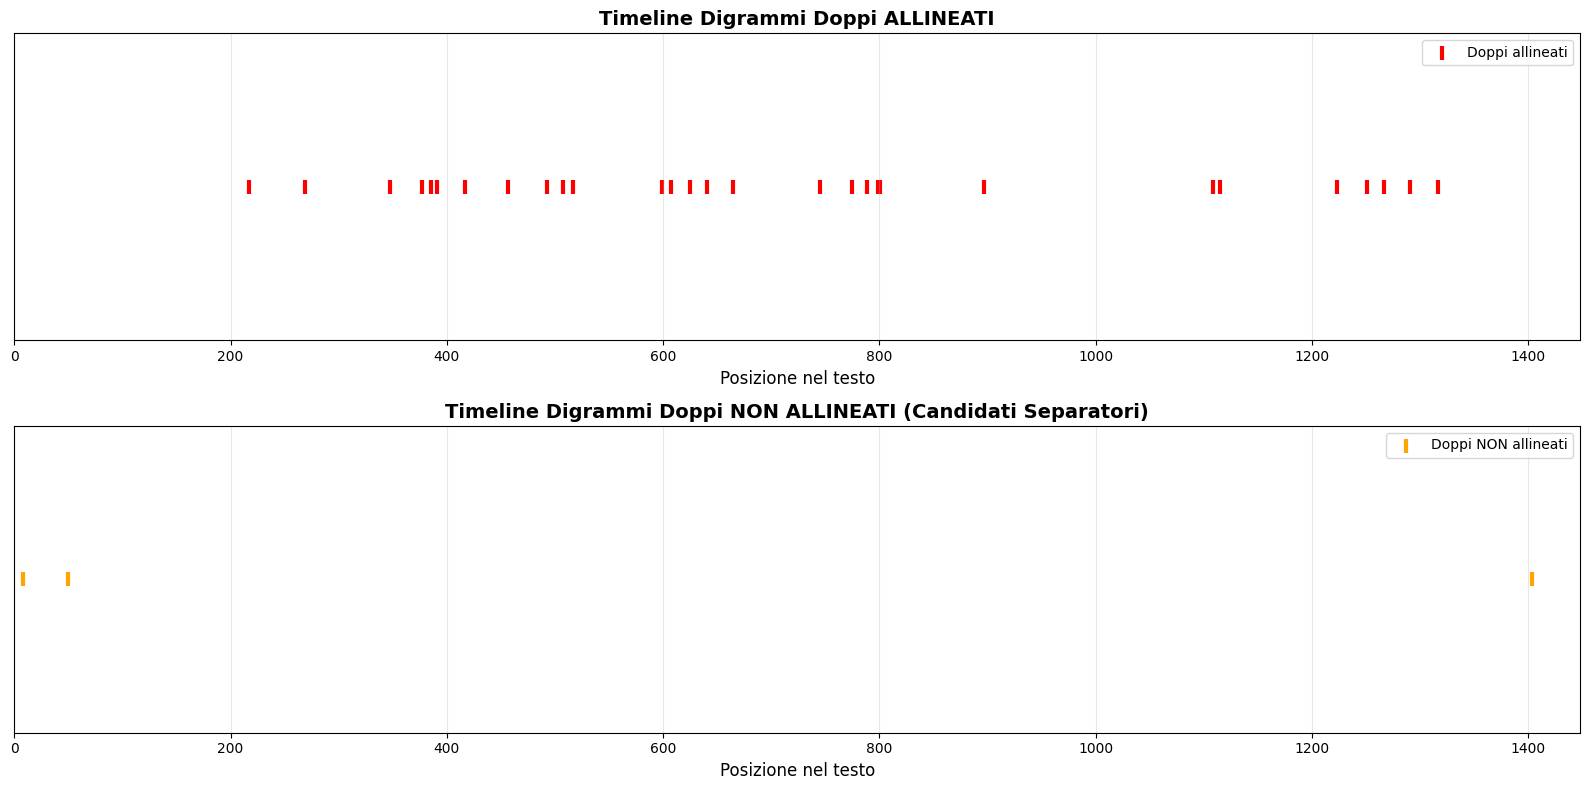

In [24]:
# Timeline doppi allineati e non allineati
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# Doppi allineati
aligned_positions = [d.position for d in adjacent_doubles if d.is_aligned]
if aligned_positions:
    ax1.scatter(aligned_positions, [1]*len(aligned_positions), 
                color='red', s=100, marker='|', linewidths=3, label='Doppi allineati')

ax1.set_xlim(0, len(ciphertext))
ax1.set_ylim(0.5, 1.5)
ax1.set_xlabel('Posizione nel testo', fontsize=12)
ax1.set_title('Timeline Digrammi Doppi ALLINEATI', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
ax1.set_yticks([])

# Doppi NON allineati
non_aligned_positions = [d.position for d in adjacent_doubles if not d.is_aligned]
if non_aligned_positions:
    ax2.scatter(non_aligned_positions, [1]*len(non_aligned_positions), 
                color='orange', s=100, marker='|', linewidths=3, label='Doppi NON allineati')

ax2.set_xlim(0, len(ciphertext))
ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel('Posizione nel testo', fontsize=12)
ax2.set_title('Timeline Digrammi Doppi NON ALLINEATI (Candidati Separatori)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

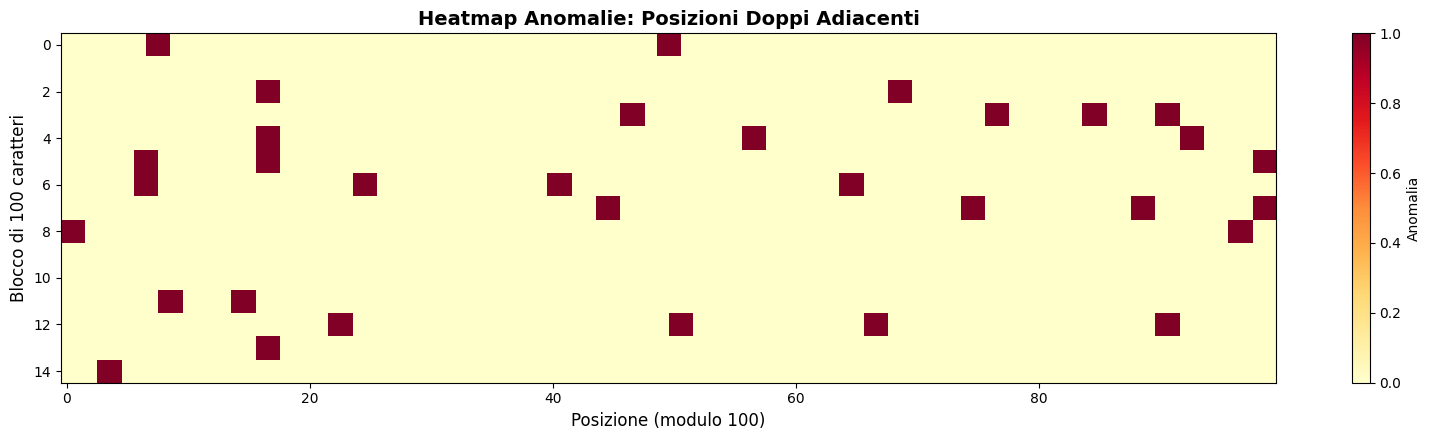


Rosso = posizioni con doppi adiacenti
Ogni riga = 100 caratteri
Totale righe = 15


In [25]:
# Heatmap anomalie per posizione
# Creiamo un array binario: 1 = posizione anomala, 0 = normale
anomaly_map = np.zeros(len(ciphertext))

for d in adjacent_doubles:
    anomaly_map[d.position - 1] = 1
    anomaly_map[d.position] = 1

# Reshape per visualizzazione (100 caratteri per riga)
chars_per_row = 100
num_rows = int(np.ceil(len(anomaly_map) / chars_per_row))
padded_length = num_rows * chars_per_row

anomaly_padded = np.pad(anomaly_map, (0, padded_length - len(anomaly_map)), constant_values=0)
anomaly_grid = anomaly_padded.reshape(num_rows, chars_per_row)

fig, ax = plt.subplots(figsize=(16, num_rows * 0.3))
im = ax.imshow(anomaly_grid, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xlabel('Posizione (modulo 100)', fontsize=12)
ax.set_ylabel('Blocco di 100 caratteri', fontsize=12)
ax.set_title('Heatmap Anomalie: Posizioni Doppi Adiacenti', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, label='Anomalia')
plt.tight_layout()
plt.show()

print(f"\nRosso = posizioni con doppi adiacenti")
print(f"Ogni riga = 100 caratteri")
print(f"Totale righe = {num_rows}")

## 13. Report Finale Automatico

Generiamo un report Markdown completo con raccomandazioni operative.

In [26]:
def generate_report() -> str:
    """
    Genera report Markdown completo dell'analisi.
    """
    report = []
    
    report.append("# Report Crittoanalisi Playfair - Analisi Anomalie\n")
    report.append("---\n\n")
    
    # 1. Sintesi Statistiche
    report.append("## 1. Sintesi Statistiche Principali\n\n")
    report.append(f"- **Lunghezza testo normalizzato**: {norm_result.normalized_length} caratteri\n")
    report.append(f"- **Parità**: {'PARI ✓' if norm_result.is_even_length else 'DISPARI ✗'}\n")
    report.append(f"- **Presenza J**: {'SÌ ✗' if norm_result.has_j else 'NO ✓'}\n")
    report.append(f"- **Lettere mancanti**: {', '.join(norm_result.missing_letters) if norm_result.missing_letters else 'Nessuna'}\n")
    report.append(f"- **Digrammi totali (offset=0)**: {len(digrams_offset0)}\n")
    report.append(f"- **Digrammi distinti (offset=0)**: {len(freq_offset0)}\n")
    report.append(f"- **Digrammi doppi allineati (offset=0)**: {len(doubles_offset0)}\n")
    report.append(f"- **Digrammi doppi allineati (offset=1)**: {len(doubles_offset1)}\n")
    report.append(f"- **Doppi adiacenti totali**: {len(adjacent_doubles)}\n")
    report.append(f"- **Doppi NON allineati**: {sum(1 for d in adjacent_doubles if not d.is_aligned)}\n\n")
    
    # 2. Compatibilità Playfair
    report.append("## 2. Compatibilità con Playfair Standard\n\n")
    
    compat_score = 0
    report.append("### Indicatori Favorevoli:\n\n")
    
    if not norm_result.has_j:
        report.append("- ✅ **Assenza di J**: compatibile con I/J unificati\n")
        compat_score += 1
    else:
        report.append("- ✗ **Presenza di J**: raro ma non impossibile\n")
    
    if norm_result.is_even_length:
        report.append("- ✅ **Lunghezza pari**: compatibile con segmentazione in digrammi\n")
        compat_score += 1
    else:
        report.append("- ✗ **Lunghezza dispari**: richiede padding\n")
    
    report.append("\n### Indicatori Sfavorevoli:\n\n")
    
    if len(doubles_offset0) > 0:
        report.append(f"- ⚠️  **{len(doubles_offset0)} digrammi doppi allineati**: incompatibile con Playfair standard puro\n")
    
    if len(adjacent_doubles) > len(doubles_offset0):
        report.append(f"- ⚠️  **Doppi non allineati presenti**: possibili separatori o sfasamenti\n")
    
    report.append("\n### Valutazione Complessiva:\n\n")
    
    if len(doubles_offset0) == 0:
        report.append("**COMPATIBILE** con Playfair standard.\n\n")
    elif len(doubles_offset0) <= 5:
        report.append("**PARZIALMENTE COMPATIBILE**: poche anomalie, probabilmente risolvibili con rimozioni minime.\n\n")
    else:
        report.append("**NON COMPATIBILE** con Playfair standard puro. Presenti anomalie strutturali significative.\n\n")
        report.append("Possibili spiegazioni:\n")
        report.append("1. Caratteri extra/separatori inseriti\n")
        report.append("2. Sfasamento nell'allineamento\n")
        report.append("3. Variante non standard di Playfair\n")
        report.append("4. Cifrario diverso\n\n")
    
    # 3. Punti Anomali Principali
    report.append("## 3. Punti Anomali Principali\n\n")
    
    if len(doubles_offset0) > 0:
        report.append("### Digrammi Doppi Allineati (offset=0):\n\n")
        report.append("| Posizione | Doppio | Precedente | Successivo | Contesto |\n")
        report.append("|-----------|--------|------------|------------|----------|\n")
        
        for _, row in doubles_offset0.head(10).iterrows():
            report.append(f"| {row['start_pos']}–{row['end_pos']} | {row['doppio']} | "
                         f"{row['digramma_precedente']} | {row['digramma_successivo']} | "
                         f"{row['contesto'][:40]}... |\n")
        
        if len(doubles_offset0) > 10:
            report.append(f"\n*...e altri {len(doubles_offset0) - 10} doppi.*\n")
        report.append("\n")
    
    non_aligned = [d for d in adjacent_doubles if not d.is_aligned]
    if len(non_aligned) > 0:
        report.append("### Doppi NON Allineati (Candidati Separatori):\n\n")
        report.append("| Posizione | Doppio | Digr.Prec | Digr.Succ |\n")
        report.append("|-----------|--------|-----------|-----------|\n")
        
        for d in non_aligned[:10]:
            report.append(f"| {d.position} | {d.double} | {d.digram_before or '--'} | {d.digram_after or '--'} |\n")
        
        report.append("\n")
    
    # 4. Rimozioni Candidate
    report.append("## 4. Rimozioni Singole Candidate\n\n")
    report.append("Le seguenti rimozioni riducono significativamente le anomalie:\n\n")
    report.append("| Rank | Posizione | Char | Doppi Dopo | Delta | Contesto |\n")
    report.append("|------|-----------|------|------------|-------|----------|\n")
    
    for i, row in df_deletions_sorted.head(10).iterrows():
        if row['delta_offset0'] < 0:
            report.append(f"| {i+1} | {row['position']} | {row['char_removed']} | "
                         f"{row['num_doubles_offset0']} | {row['delta_offset0']:+d} | "
                         f"{row['context'][:40]}... |\n")
    
    report.append("\n")
    
    # 5. Rimozioni Multiple
    report.append("## 5. Rimozioni Multiple Candidate\n\n")
    report.append("Combinazioni minime che minimizzano anomalie:\n\n")
    report.append("| Rank | Posizioni | Chars | Doppi Dopo | Delta |\n")
    report.append("|------|-----------|-------|------------|-------|\n")
    
    for i, row in df_multi_sorted.head(10).iterrows():
        if row['delta_offset0'] < 0:
            report.append(f"| {i+1} | {row['positions']} | {row['chars_removed']} | "
                         f"{row['num_doubles_offset0']} | {row['delta_offset0']:+d} |\n")
    
    report.append("\n")
    
    # 6. Raccomandazioni
    report.append("## 6. Raccomandazioni Operative\n\n")
    
    if len(doubles_offset0) == 0:
        report.append("1. ✅ **Procedere con attacco Playfair standard**\n")
        report.append("2. Usare tecniche di hill-climbing o simulated annealing\n")
        report.append("3. Testare con dizionario italiano\n\n")
    else:
        report.append("### Varianti da Testare:\n\n")
        
        if len(df_deletions_sorted[df_deletions_sorted['delta_offset0'] < -3]) > 0:
            best_single = df_deletions_sorted.iloc[0]
            report.append(f"1. **Rimozione posizione {best_single['position']}** ('{best_single['char_removed']}')\n")
            report.append(f"   - Riduce doppi da {len(doubles_offset0)} a {best_single['num_doubles_offset0']}\n")
            report.append(f"   - Nuova lunghezza: {best_single['new_length']} ({'pari' if best_single['is_even'] else 'dispari'})\n\n")
        
        if len(df_multi_sorted[df_multi_sorted['delta_offset0'] < -5]) > 0:
            best_multi = df_multi_sorted.iloc[0]
            report.append(f"2. **Rimozione multipla posizioni {best_multi['positions']}**\n")
            report.append(f"   - Riduce doppi da {len(doubles_offset0)} a {best_multi['num_doubles_offset0']}\n")
            report.append(f"   - Nuova lunghezza: {best_multi['new_length']} ({'pari' if best_multi['is_even'] else 'dispari'})\n\n")
        
        report.append("3. **Testare offset=1** se ha meno anomalie\n\n")
        
        report.append("### Prossimi Passi:\n\n")
        report.append("1. Generare varianti del testo con le rimozioni candidate\n")
        report.append("2. Applicare attacco Playfair a ciascuna variante\n")
        report.append("3. Verificare leggibilità plaintext ottenuto\n")
        report.append("4. Validare ipotesi separatori con plaintext decifrato\n")
        report.append("5. Se fallisce, considerare cifrari alternativi\n\n")
    
    # 7. Limiti Analisi
    report.append("## 7. Limiti dell'Analisi\n\n")
    report.append("**Questa analisi si basa SOLO sul ciphertext**. Non può:\n\n")
    report.append("- ❌ Confermare che sia effettivamente Playfair\n")
    report.append("- ❌ Identificare con certezza i separatori\n")
    report.append("- ❌ Verificare pattern del plaintext (es: finali di frase con vocale)\n")
    report.append("- ❌ Distinguere tra errore e caratteristica intenzionale\n\n")
    report.append("**Le rimozioni proposte sono IPOTESI DA TESTARE**, non certezze.\n\n")
    
    report.append("---\n")
    report.append(f"\n*Report generato automaticamente - {len(ciphertext)} caratteri analizzati*\n")
    
    return ''.join(report)


# Generazione report
markdown_report = generate_report()

with open(output_dir / 'cryptanalysis_report.md', 'w', encoding='utf-8') as f:
    f.write(markdown_report)

print("✅ Report generato: cryptanalysis_report.md")
print(f"\nDimensione report: {len(markdown_report)} caratteri")

✅ Report generato: cryptanalysis_report.md

Dimensione report: 4629 caratteri


## 14. Conclusioni Operative

Rispondiamo alle domande chiave dell'analisi.

In [27]:
print("="*80)
print("CONCLUSIONI OPERATIVE")
print("="*80)
print()

# 1. Compatibilità
print("❓ Il testo è compatibile con Playfair standard puro?")
if len(doubles_offset0) == 0:
    print("   ✅ SÌ - Nessuna anomalia rilevata\n")
elif len(doubles_offset0) <= 5:
    print(f"   ⚠️  PARZIALMENTE - {len(doubles_offset0)} anomalie minori\n")
else:
    print(f"   ❌ NO - {len(doubles_offset0)} digrammi doppi incompatibili con Playfair standard\n")

# 2. Doppi offset 0
print(f"❓ Quanti digrammi doppi illegali ci sono con offset 0?")
print(f"   📊 {len(doubles_offset0)} digrammi doppi\n")

# 3. Doppi offset 1
print(f"❓ Quanti con offset 1?")
print(f"   📊 {len(doubles_offset1)} digrammi doppi\n")

# 4. Doppi non allineati
non_aligned_count = sum(1 for d in adjacent_doubles if not d.is_aligned)
print(f"❓ Esistono doppi non allineati sospetti?")
if non_aligned_count > 0:
    print(f"   ⚠️  SÌ - {non_aligned_count} doppi non allineati (candidati separatori)\n")
else:
    print("   ✅ NO - Tutti i doppi sono allineati\n")

# 5. Top 10 punti sospetti
print("❓ Quali sono i primi 10 punti più sospetti?")
top_suspicious = df_deletions_sorted.head(10)
for i, row in top_suspicious.iterrows():
    if row['delta_offset0'] < 0:
        print(f"   {i+1}. Posizione {row['position']:4d} ('{row['char_removed']}') - "
              f"riduce da {len(doubles_offset0)} a {row['num_doubles_offset0']} doppi")
print()

# 6. Rimozioni singole efficaci
effective_single = df_deletions_sorted[df_deletions_sorted['delta_offset0'] < -3]
print("❓ Ci sono rimozioni singole che riducono drasticamente le anomalie?")
if len(effective_single) > 0:
    print(f"   ✅ SÌ - {len(effective_single)} rimozioni riducono di almeno 3 doppi\n")
else:
    print("   ❌ NO - Nessuna rimozione singola molto efficace\n")

# 7. Rimozioni multiple
effective_multi = df_multi_sorted[df_multi_sorted['delta_offset0'] < -5]
print("❓ Ci sono combinazioni minime di rimozioni che rendono il testo più compatibile?")
if len(effective_multi) > 0:
    print(f"   ✅ SÌ - {len(effective_multi)} combinazioni riducono di almeno 5 doppi\n")
    best = effective_multi.iloc[0]
    print(f"   🏆 Migliore: posizioni {best['positions']} → {best['num_doubles_offset0']} doppi residui\n")
else:
    print("   ❌ NO - Combinazioni multiple non molto efficaci\n")

# 8. Separatori di blocco
print("❓ Ha senso trattare alcuni doppi come separatori di blocco/frase?")
if non_aligned_count > 0:
    print(f"   ⚠️  SÌ - {non_aligned_count} doppi non allineati sono candidati plausibili")
    print("   ℹ️  Validazione possibile solo dopo decifratura\n")
else:
    print("   ❌ NO - Nessun doppio non allineato rilevato\n")

# 9. Variante raccomandata
print("❓ Quale variante del testo conviene provare per un successivo attacco Playfair?")
if len(doubles_offset0) == 0:
    print("   ✅ Usare il testo normalizzato originale")
elif len(effective_single) > 0:
    best_single = df_deletions_sorted.iloc[0]
    print(f"   🎯 Variante 1: rimuovere posizione {best_single['position']} ('{best_single['char_removed']}')")
    if len(effective_multi) > 0:
        best_multi = df_multi_sorted.iloc[0]
        print(f"   🎯 Variante 2: rimuovere posizioni {best_multi['positions']}")
    if len(doubles_offset1) < len(doubles_offset0) - 3:
        print(f"   🎯 Variante 3: usare offset=1 (solo {len(doubles_offset1)} doppi)")
else:
    print("   ⚠️  Nessuna variante singola molto promettente")
    print("   💡 Considerare analisi manuale o cifrario alternativo")

print()
print("="*80)
print("📁 TUTTI I RISULTATI SALVATI IN: output/")
print("="*80)

CONCLUSIONI OPERATIVE

❓ Il testo è compatibile con Playfair standard puro?
   ❌ NO - 29 digrammi doppi incompatibili con Playfair standard

❓ Quanti digrammi doppi illegali ci sono con offset 0?
   📊 29 digrammi doppi

❓ Quanti con offset 1?
   📊 3 digrammi doppi

❓ Esistono doppi non allineati sospetti?
   ⚠️  SÌ - 3 doppi non allineati (candidati separatori)

❓ Quali sono i primi 10 punti più sospetti?
   1. Posizione   51 ('G') - riduce da 29 a 1 doppi
   2. Posizione   52 ('B') - riduce da 29 a 1 doppi
   3. Posizione   50 ('G') - riduce da 29 a 1 doppi
   4. Posizione  216 ('Y') - riduce da 29 a 1 doppi
   5. Posizione  217 ('L') - riduce da 29 a 1 doppi
   6. Posizione  218 ('L') - riduce da 29 a 1 doppi
   7. Posizione    9 ('I') - riduce da 29 a 2 doppi
   8. Posizione    8 ('I') - riduce da 29 a 2 doppi
   9. Posizione  268 ('N') - riduce da 29 a 2 doppi
   10. Posizione   49 ('N') - riduce da 29 a 2 doppi

❓ Ci sono rimozioni singole che riducono drasticamente le anomalie?
 

---

## Fine Analisi

**Recap File Generati**:

1. `normalized_cipher.txt` - Testo normalizzato
2. `digrams_offset0.csv` - Digrammi con offset=0
3. `digrams_offset1.csv` - Digrammi con offset=1
4. `double_digrams_offset0.csv` - Doppi allineati offset=0
5. `double_digrams_offset1.csv` - Doppi allineati offset=1
6. `adjacent_doubles.csv` - Tutti i doppi adiacenti
7. `deletion_candidates.csv` - Rimozioni singole candidate
8. `multi_deletion_candidates.csv` - Rimozioni multiple
9. `repeated_sequences.csv` - Sequenze ripetute
10. `cryptanalysis_report.md` - **Report completo**

**Prossimi Passi Suggeriti**:

1. Leggere il `cryptanalysis_report.md`
2. Generare varianti del testo con rimozioni candidate
3. Applicare attacco Playfair (es: simulated annealing)
4. Validare risultati con dizionario italiano
5. Verificare ipotesi separatori su plaintext decifrato

---